In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats


def qqplot(data, dist=stats.norm, dist_params=(), ax=None):
    data = np.asarray(data)
    n = len(data)

    sample_quantiles = np.sort(data)
    probs = (np.arange(1, n + 1) - 0.5) / n
    theoretical_quantiles = dist.ppf(probs, *dist_params)

    X = np.column_stack([theoretical_quantiles, np.ones(n)])
    k, b = np.linalg.lstsq(X, sample_quantiles, rcond=None)[0]

    x_min, x_max = theoretical_quantiles[[0, -1]]
    pad = (x_max - x_min) * 0.05
    x_line = np.array([x_min - pad, x_max + pad])
    y_line = k * x_line + b

    if ax is None:
        _, ax = plt.subplots(figsize=(6, 6))

    ax.scatter(theoretical_quantiles, sample_quantiles, s=20, color="b", alpha=0.7, zorder=3)

    ax.plot(x_line, y_line, color="r", linewidth=1.5, zorder=4)

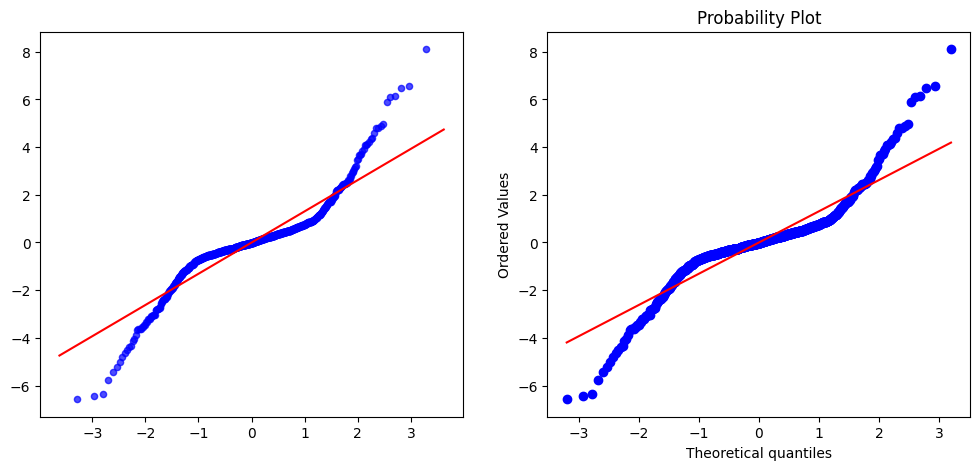

In [5]:
n = 1000

p_small = 0.7
sigma_small = 0.5
sigma_large = 2.5

n_small = int(n * p_small)
n_large = n - n_small

group_small = np.random.normal(loc=0, scale=sigma_small, size=n_small)
group_large = np.random.normal(loc=0, scale=sigma_large, size=n_large)

data = np.concatenate([group_small, group_large])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

qqplot(data, ax=axes[0])

stats.probplot(data, dist="norm", plot=axes[1]);